**Code Summary**

The Jupyter cell loads the raw *Eurasian Otter* dataset via `DataImporter`, then calls `create_train_test_split_otter` to deterministically build three splits:

1. **Inference** – all footprints from the “Fieldprints Portugal” source.
2. **Test** – every DNA-confirmed footprint from Lower Saxony plus fixed, seed‑controlled samples of individuals from “Own Data Collection” (3♀, 3♂) and “Vetrecova et al.” (2♀, 2♂).
3. **Train** – all remaining individuals.

The train data are assigned fold IDs using `_make_folds` (group‑stratified K‑fold with `NUM_FOLDS = 3`), ensuring footprints from the same individual stay in a single fold. Each split is stored as a Parquet file under `data/splits/eurasian_otter/`.

Finally, `run_summary` computes dataset statistics and saves them (including plots) to `results/data/eurasian_otter_summary.csv` and the corresponding figure directory.



🔄 Starte Otter-Splitting...
🛰️ Inference-Split – 81 Zeilen
↪️ Inference 'dataorigin': ['Fieldprints Portugal']
↪️ Inference 'sex' unique: ['unknown']

🧹 df_clean – 547 Zeilen (ohne Portugal)
🧾 dataorigin: ['Vetrecova et al' 'Own Data Collection' 'Fieldprints Lower Saxony']
🧬 sex: ['f' 'm']
🆔 individual_id: 41

🔬 Erzeuge Test-Split...
✅ Test-Split fertig – 152 Zeilen
👤 Test-Individuals: 14
📊 Test 'dataorigin': dataorigin
Own Data Collection         76
Vetrecova et al             40
Fieldprints Lower Saxony    36
🧬 Test 'sex': sex
f    86
m    66

🧠 Train-Split – 395 Zeilen
👤 Train-Individual IDs: 27
📊 Train 'dataorigin': dataorigin
Own Data Collection    343
Vetrecova et al         52
🧬 Train 'sex': sex
f    220
m    175

🎲 Berechne Fold-Zuordnung...

✅ Fold method used: stratified_group
📊 Fold-Verteilung:
Fold
0    123
1    142
2    130
Name: count, dtype: int64

[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inferen

C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids


[CAPTION] Summary counts for all species
[CAPTION] Summary counts for all species
[CAPTION] Counts for lutra lutra
[CAPTION] Counts for lutra lutra
[CAPTION] Fraction of footprints per split
[CAPTION] Fraction of footprints per split


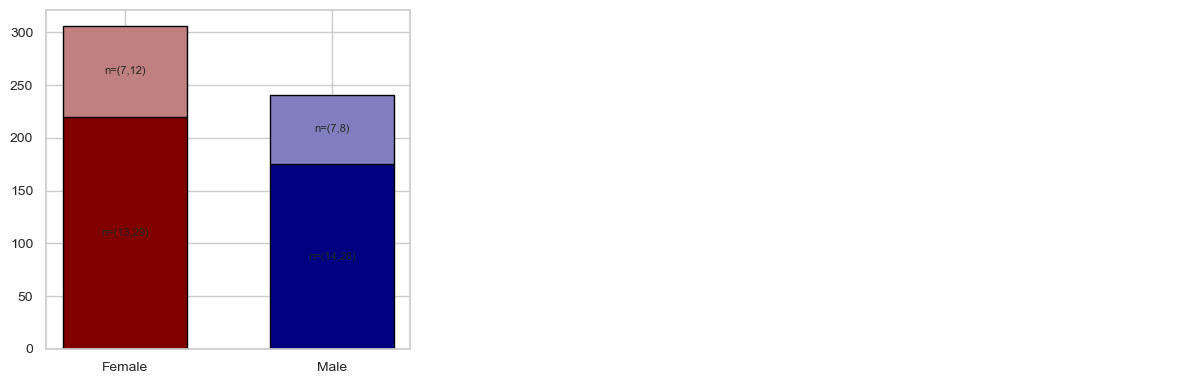

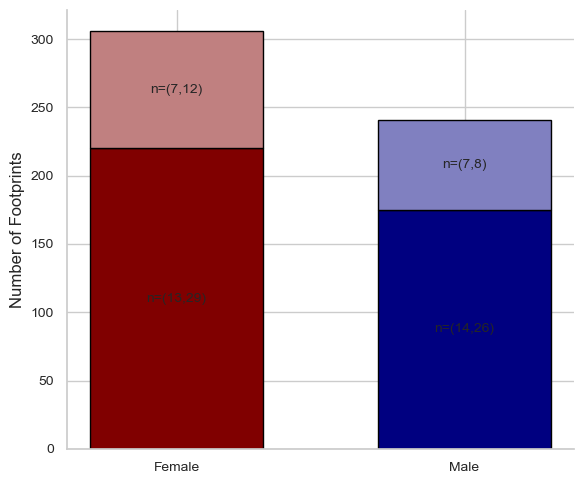

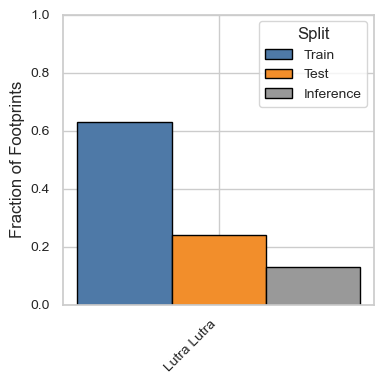

In [1]:
from pathlib import Path

from FIT_python.data_split_and_summary.data_import_wrapper import DataImporter
from FIT_python.data_split_and_summary.split_utils import (
    create_train_test_split_otter,
    _make_folds,
)
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.config import (
    RAW_DIR,
    SPLITS_DIR,
    RESULTS_DATA_DIR,
    DEFAULT_TARGETS,
    GROUP_COL,
    NUM_FOLDS,
)

# --- 1. Load the raw Eurasian otter table
importer = DataImporter(RAW_DIR, target_cols=DEFAULT_TARGETS)
dfs = importer.run()
otter_key = next(k for k in dfs if "otter" in k.lower())
df = dfs[otter_key]

# --- 2. Create deterministic train/test/inference splits
train_df, test_df, inf_df = create_train_test_split_otter(df)

# --- 3. Assign folds for cross‑validation
y_train = train_df["sex"].map({"f": 0, "m": 1})
folds, _ = _make_folds(train_df, y_train, n_splits=NUM_FOLDS, group_col=GROUP_COL)
train_df = train_df.assign(Fold=folds)

# --- 4. Save split files
split_dir = SPLITS_DIR / "eurasian_otter"
split_dir.mkdir(parents=True, exist_ok=True)
train_df.to_parquet(split_dir / "train.parquet", index=False)
test_df.to_parquet(split_dir / "test.parquet", index=False)
inf_df.to_parquet(split_dir / "inference.parquet", index=False)

# --- 5. Generate summary statistics and plots
run_summary(
    split_dir,
    RESULTS_DATA_DIR / "eurasian_otter_summary.csv",
    RESULTS_DATA_DIR / "eurasian_otter_fig",
)


**Otter Data Splitting Summary**

- **Inference split:** 81 rows from *Fieldprints Portugal*, all labeled with unknown sex.
- **Filtered data (`df_clean`):** 547 rows remaining after removing Portugal samples, spanning origins *Vetrecova et al.*, *Own Data Collection*, and *Fieldprints Lower Saxony*. Contains 41 unique individuals (sexes “f” and “m”).
- **Test split:** Created with 152 rows across 14 individuals. Distribution by origin:  
  - Own Data Collection – 76  
  - Vetrecova et al. – 40  
  - Fieldprints Lower Saxony – 36  
  Sex balance: 86 “f” vs. 66 “m”.
- **Train split:** Remaining 395 rows from 27 individuals.  
- A summary step was attempted but skipped because `eurasian_otter_summary.csv` already exists.
